In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [3]:
x = df.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
y = df['ps_z']

In [4]:
x.head()

,lat,long,age,q_ps
0,48.7500,-127.75,2.906279,277.518538
1,47.8983,-127.20,4.359262,226.597009
2,47.8983,-127.65,3.190760,264.858297
3,48.6833,-126.87,5.543758,200.936360
4,48.6850,-126.87,5.543758,200.936360


In [5]:
x.shape

(3691, 4)

In [6]:
y.head()

0    3096.673436
1    3230.759601
2    3125.194460
3    3324.081515
4    3324.081515
Name: ps_z, dtype: float64

In [7]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [8]:
x_train.shape

(2952, 4)

this is the raw validation data

In [9]:
x_test.shape

(739, 4)

In [10]:
x_train.describe().round(3)

,lat,long,age,q_ps
count,2952.000,2952.000,2952.000,2952.000
mean,48.175,-128.319,1.760,578.503
std,0.322,0.657,1.641,639.345
min,47.686,-129.505,0.009,182.939
25%,47.885,-128.710,0.592,262.388
50%,48.327,-128.640,0.912,495.320
75%,48.455,-127.786,3.251,615.104
max,48.997,-126.223,6.688,5015.915


In [11]:
x_test.describe().round(3)

,lat,long,age,q_ps
count,739.000,739.000,739.000,739.000
mean,48.155,-128.304,1.802,570.054
std,0.323,0.664,1.643,637.030
min,47.686,-129.398,0.009,185.049
25%,47.872,-128.710,0.592,262.388
50%,48.168,-128.638,0.912,495.320
75%,48.453,-127.783,3.251,615.104
max,48.907,-126.282,6.537,5015.915


In [12]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

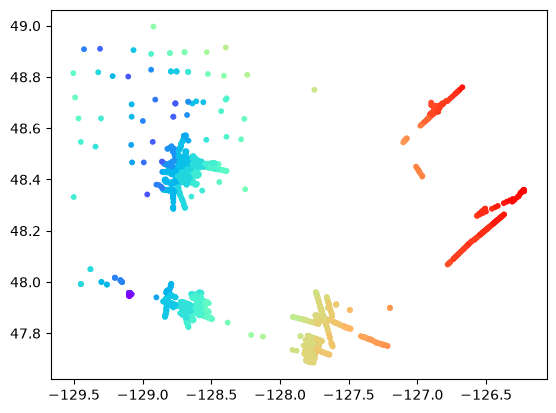

In [13]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

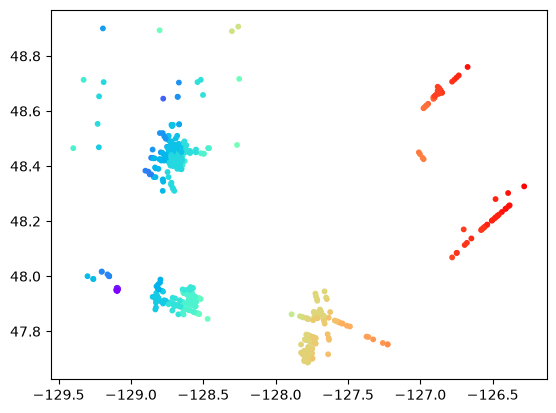

In [14]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [15]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [16]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 2952, number of used features: 4
[LightGBM] [Info] Start training from score 2917.295591


In [17]:
y_pred = model.predict(x_test)

In [18]:
y_pred.shape

(739,)

In [19]:
y_pred, y_pred.shape

(array([2784.96421778, 2916.73990271, 2754.95410268, 2825.8302429 ,
        2878.24270964, 3375.54885261, 2769.2107178 , 3122.28645775,
        2559.92062603, 2825.78119391, 3125.19711352, 2878.24471809,
        2769.2107178 , 3131.07918001, 3122.49053278, 2811.74899621,
        2769.2107178 , 2811.74899621, 2557.72679755, 2760.90278536,
        2878.24698669, 2769.2107178 , 3162.05809481, 2533.4480358 ,
        3122.12493578, 2769.2107178 , 2769.2107178 , 2747.91389337,
        3131.07918001, 2811.74899621, 2769.2107178 , 2769.2107178 ,
        3131.07918001, 2855.80539832, 2769.2107178 , 3337.11706312,
        2769.2107178 , 3323.96891371, 2882.53259902, 2811.74899621,
        2747.91389337, 2769.2107178 , 3131.07918001, 2878.35717187,
        3131.07918001, 3131.07918001, 3125.16673366, 2705.05277416,
        2769.2107178 , 2878.24698669, 2813.64635774, 2878.23768591,
        2769.2107178 , 2811.74899621, 2811.73695394, 3290.30821711,
        3222.87335803, 2769.2107178 , 3122.28645

In [20]:
residuals = y_test - y_pred

negative mean: overpredicting

In [21]:
residuals.head(), residuals.describe()

(2039   -0.007817
 646    -0.516612
 1650   -0.012697
 2644   -0.012293
 1237    0.002502
 Name: ps_z, dtype: float64,
 count    739.000000
 mean       0.023450
 std        0.813682
 min      -12.687556
 25%       -0.012293
 50%        0.000167
 75%        0.004159
 max        7.603762
 Name: ps_z, dtype: float64)

In [22]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [23]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_ps_z_residuals.csv', index=False)

with open('..\\created_data\\seg2_ps_z_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

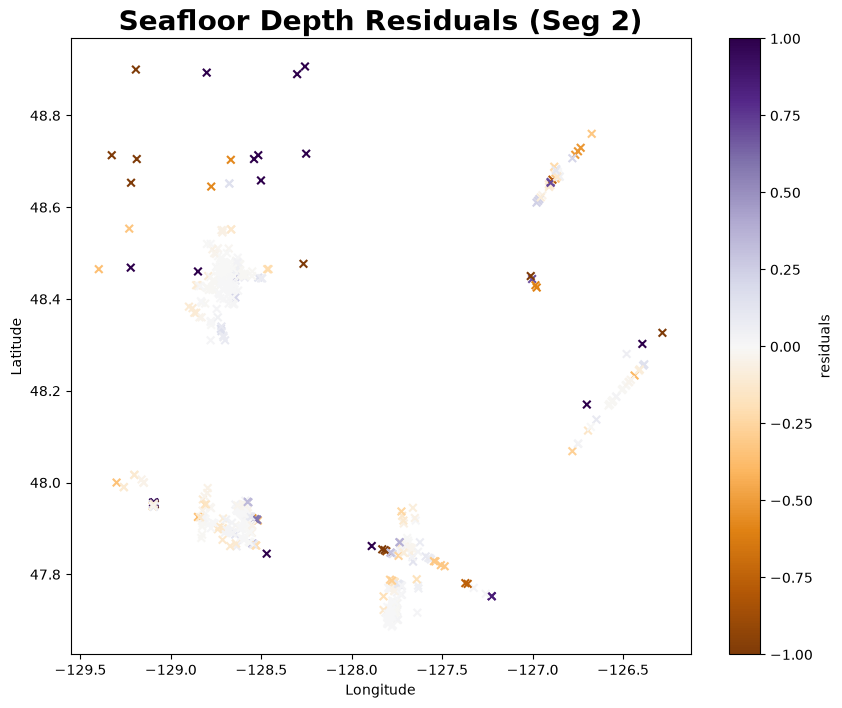

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seafloor Depth Residuals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_ps_z_seg2.png', dpi=400)
plt.show()

## now we ... predict!

In [38]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [39]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [40]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [41]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ps'], (long, lat), method='linear')

In [42]:
age_interp.shape, hf_interp.shape

((250, 250), (250, 250))

np.vstack stacks arrays as new rows

In [43]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel()]).T

In [44]:
lola.shape

(62500, 4)

In [45]:
lola_pred = model.predict(lola)

In [46]:
lola_pred[0:5]

array([2886.57528337, 2886.57528337, 2886.57528337, 2886.57528337,
       2886.57528337])

In [47]:
lola_pred = lola_pred.reshape(long.shape)

In [48]:
lola_pred.shape

(250, 250)

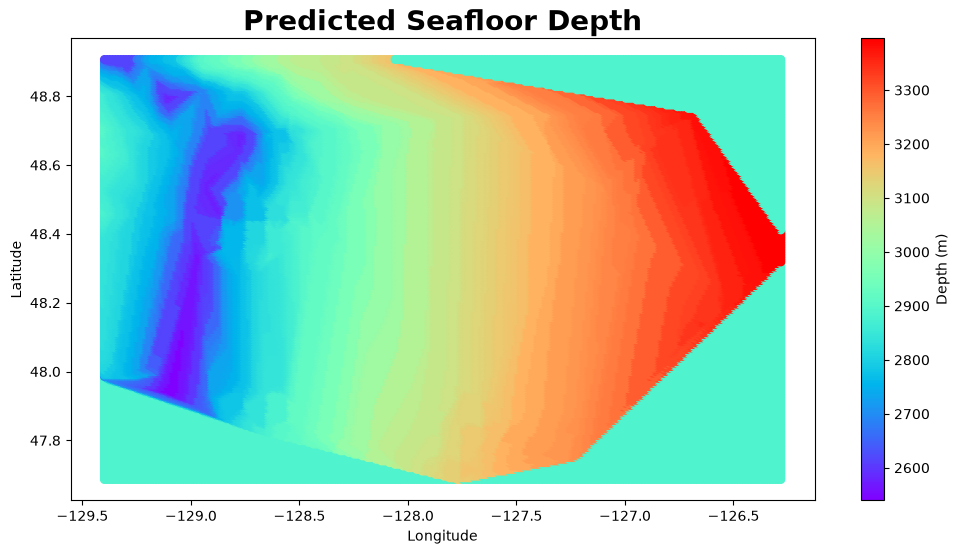

In [60]:
plt.figure(figsize=(12, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Seafloor Depth', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\skunny_seg2_ps_z_pred_{sp}.png', dpi=400)
plt.show()

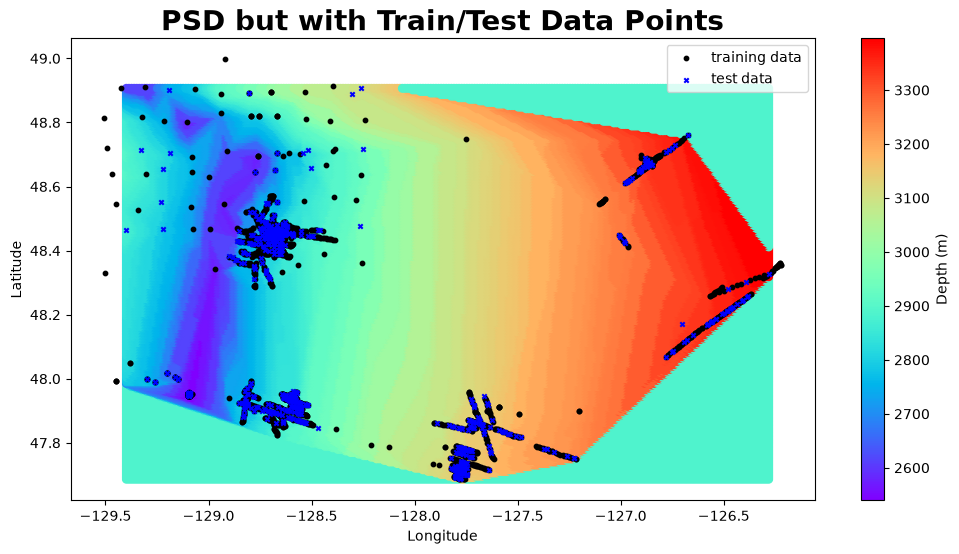

In [61]:
plt.figure(figsize=(12,6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=10, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=10, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('PSD but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')

plt.savefig(f'..\\figs\\skunny_seg2_ps_z_pnts_pred_{sp}.png', dpi=400)
plt.show()